# Random walks and anomalous diffusion

This notebook simulates five random-walk models, checks their mean-squared
displacement (MSD) against theory, and estimates the anomalous-diffusion
exponent with honest uncertainty.

For a walk $\mathbf r(t)$ the ensemble MSD scales as
$\langle|\mathbf r(t)|^2\rangle \propto t^{\alpha}$:
- $\alpha = 1$ is normal diffusion (lattice and Gaussian walks);
- $\alpha < 1$ is sub-diffusion;
- $\alpha > 1$ is super-diffusion.

Fractional Brownian motion (fBm) with Hurst exponent $H$ has $\alpha = 2H$.
See [`docs/methods.md` §1](../docs/methods.md#1-random-walks-and-anomalous-diffusion).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pcc_vizforge.plots.style import apply_matplotlib_style

apply_matplotlib_style()
SEED = 20240101

## 1. Simulate every model

All models are normalised so that the single-step MSD equals `step_size**2`.

In [2]:
from pcc_vizforge.generators import RandomWalkGenerator
from pcc_vizforge.generators.random_walk import frame_to_positions, theoretical_msd
from pcc_vizforge.analysis import diffusion

models = {
    "lattice": {},
    "correlated (ρ=0.6)": {"model": "correlated", "persistence": 0.6},
    "fBm (H=0.3)": {"model": "fbm", "hurst": 0.3},
    "fBm (H=0.75)": {"model": "fbm", "hurst": 0.75},
}
ensembles = {}
for name, kw in models.items():
    gen = RandomWalkGenerator(n_steps=1000, n_walks=400, dimensions=2, **({"model": "lattice"} | kw))
    ensembles[name] = (gen, frame_to_positions(gen.generate(seed=SEED)))
    print(f"{name:20s} -> positions array {ensembles[name][1].shape}")

lattice              -> positions array (400, 1000, 2)
correlated (ρ=0.6)   -> positions array (400, 1000, 2)
fBm (H=0.3)          -> positions array (400, 1000, 2)
fBm (H=0.75)         -> positions array (400, 1000, 2)


## 2. Ensemble MSD vs. closed-form theory

The dashed lines are the exact theoretical MSDs from `theoretical_msd`, not fits.

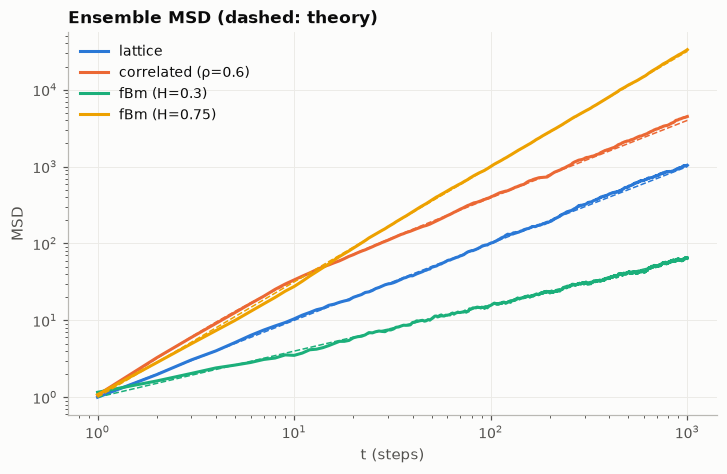

In [3]:
from pcc_vizforge.plots.style import series_color

fig, ax = plt.subplots(figsize=(6.5, 4.2), layout="constrained")
t = np.arange(1, 1001, dtype=float)
for i, (name, (gen, pos)) in enumerate(ensembles.items()):
    msd, sem = diffusion.ensemble_msd(pos)
    ax.plot(t, msd, color=series_color(i), label=name)
    ax.plot(t, theoretical_msd(gen.params, t), color=series_color(i), ls="--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="t (steps)", ylabel="MSD", title="Ensemble MSD (dashed: theory)")
ax.legend();

## 3. Estimating α with honest uncertainty

MSD values at neighbouring lags are strongly correlated, so a naive
regression CI is far too narrow. `bootstrap_msd_exponent` resamples
**walks**, the independent unit, and refits.

In [4]:
rows = []
for name, (gen, pos) in ensembles.items():
    msd, sem = diffusion.ensemble_msd(pos)
    naive = diffusion.fit_msd_exponent(t, msd, sigma=sem)
    boot = diffusion.bootstrap_msd_exponent(pos, seed=SEED)
    true = 2 * gen.params.hurst if gen.params.model == "fbm" else (1.0 if gen.params.model == "lattice" else np.nan)
    rows.append({"model": name, "true α (long-time)": true, "α̂": boot.alpha,
                 "naive CI": f"[{naive.alpha_ci[0]:.3f}, {naive.alpha_ci[1]:.3f}]",
                 "bootstrap CI": f"[{boot.alpha_ci[0]:.3f}, {boot.alpha_ci[1]:.3f}]",
                 "regime": boot.regime})
pd.DataFrame(rows).round(3)

,model,true α (long-time),α̂,naive CI,bootstrap CI,regime
0,lattice,1.0,1.009,"[1.022, 1.027]","[0.991, 1.027]",normal
1,correlated (ρ=0.6),NaN,1.146,"[1.069, 1.075]","[1.124, 1.170]",superdiffusive
2,fBm (H=0.3),0.6,0.594,"[0.606, 0.610]","[0.575, 0.612]",subdiffusive
3,fBm (H=0.75),1.5,1.514,"[1.514, 1.517]","[1.491, 1.538]",superdiffusive


The persistent walk has no single exponent. It is ballistic ($\alpha\to 2$)
for $t \ll 1/(1-\rho)$ and diffusive at long times, so a global fit
averages the two regimes. Fitting only long lags recovers normal diffusion:

In [5]:
gen, pos = ensembles["correlated (ρ=0.6)"]
long_lags = diffusion.log_spaced_lags(1001)
long_lags = long_lags[(long_lags >= 50) & (long_lags <= 1000)]
diffusion.bootstrap_msd_exponent(pos, lags=long_lags, seed=SEED).alpha_ci

(0.9954232130027324, 1.100247044415428)

## 4. Diagnostic figure and DFA

Detrended fluctuation analysis of the increments gives an independent estimate of $H$.

DFA Hurst estimate: 0.326 ± 0.003 (true 0.3)


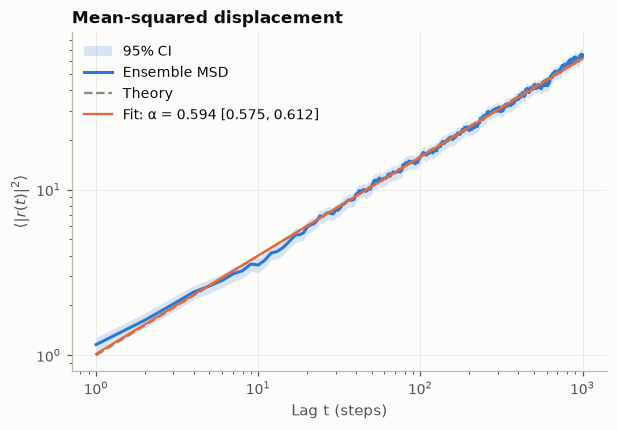

In [6]:
from pcc_vizforge.plots import diagnostics as D

gen, pos = ensembles["fBm (H=0.3)"]
msd, sem = diffusion.ensemble_msd(pos)
D.msd_figure(t, msd, sem, theory=theoretical_msd(gen.params, t), fit=diffusion.bootstrap_msd_exponent(pos, seed=SEED))

increments = np.diff(pos[..., 0], axis=1, prepend=0.0)
h = [diffusion.dfa(x)[0].alpha for x in increments[:100]]
print(f"DFA Hurst estimate: {np.mean(h):.3f} ± {np.std(h, ddof=1) / np.sqrt(len(h)):.3f} (true 0.3)")

DFA slightly **overestimates** $H$ for short anti-persistent series ($H < 0.5$).
This is a known small-scale bias of DFA-1. It shrinks with longer series, as
the test suite checks on $2^{14}$ points. The MSD bootstrap above is the more
reliable estimator here.

## 5. Ergodicity

For Brownian motion, the time average over one long trajectory equals the
ensemble average, and the ergodicity-breaking parameter is
$\mathrm{EB}(\Delta)\approx 4\Delta/3T$.

In [7]:
gen = RandomWalkGenerator(model="gaussian", n_steps=2000, n_walks=200)
pos = frame_to_positions(gen.generate(seed=SEED))
lags, tamsd = diffusion.time_averaged_msd(pos, [1, 10, 100])
pd.DataFrame({"lag": lags, "EB (measured)": diffusion.ergodicity_breaking_parameter(tamsd),
              "EB (theory 4Δ/3T)": 4 * lags / (3 * 2000)}).round(4)

,lag,EB (measured),EB (theory 4Δ/3T)
0,1,0.0011,0.0007
1,10,0.0071,0.0067
2,100,0.0775,0.0667
